# Loading and Organizing ERA5 Soil Moisture Data

This notebook loads ERA5 soil moisture data from netCDF files and organizes them into a single xarray Dataset or DataArray.

## Data Source
- **Location**: `Data/ERA5/soil moisture/`
- **Format**: netCDF files (`.nc`)
- **Naming pattern**: `soil_moisture_YYYY_MM.nc` (monthly files)

In [1]:
# Import necessary libraries
import os
import glob
import xarray as xr
import numpy as np
import numba
import pandas as pd
import geopandas as gpd
import regionmask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Set display options for better readability
xr.set_options(display_style='html')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## Step 1: Locate all netCDF files

In [20]:
# Define the path to the soil moisture data folder
data_path = os.path.expanduser('~/CE/ag/Data/ERA5/soil moisture/')

# Get all netCDF files in the folder
nc_files = sorted(glob.glob(os.path.join(data_path, '*.nc')))

print(f"Found {len(nc_files)} netCDF files")
print(f"\nFirst 5 files:")
for f in nc_files[:5]:
    print(f"  {os.path.basename(f)}")
print(f"\nLast 5 files:")
for f in nc_files[-5:]:
    print(f"  {os.path.basename(f)}")

Found 528 netCDF files

First 5 files:
  soil_moisture_1980_01.nc
  soil_moisture_1980_02.nc
  soil_moisture_1980_03.nc
  soil_moisture_1980_04.nc
  soil_moisture_1980_05.nc

Last 5 files:
  soil_moisture_2023_08.nc
  soil_moisture_2023_09.nc
  soil_moisture_2023_10.nc
  soil_moisture_2023_11.nc
  soil_moisture_2023_12.nc


## Step 2: Inspect a single file structure

In [21]:
# Open a single file to inspect its structure
sample_file = nc_files[0]
print(f"Inspecting: {os.path.basename(sample_file)}\n")

# Open without loading into memory (lazy loading)
sample_ds = xr.open_dataset(sample_file)

print("Dataset structure:")
print(sample_ds)


Inspecting: soil_moisture_1980_01.nc

Dataset structure:
<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 744, latitude: 17, longitude: 21)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 6kB 1980-01-01 ... 1980-01-31T23:...
  * latitude    (latitude) float64 136B 54.0 53.75 53.5 ... 50.5 50.25 50.0
  * longitude   (longitude) float64 168B 3.0 3.25 3.5 3.75 ... 7.25 7.5 7.75 8.0
    expver      (valid_time) <U4 12kB ...
Data variables:
    swvl1       (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-28T08:27 GRIB to CDM+CF via cfgrib-0.9.1...


## Step 3: Load all files into a single Dataset and explore data
    


In [22]:
soil_moisture_ds = xr.open_mfdataset(
    nc_files,
    combine='by_coords',  # Automatically combine along matching coordinates (e.g., time)
    parallel=True,        # Use parallel reading for faster loading
    chunks={'time': 100}  # Chunk along time dimension for better memory management
)

# Display dataset summary
print("Dataset Summary:")
print("="*60)
print(f"Dimensions: {dict(soil_moisture_ds.dims)}")
print(f"\nCoordinates:")
print(f"\nData Variables:")
for var_name, var_data in soil_moisture_ds.data_vars.items():
    print(f"  {var_name}:")
    print(f"    Shape: {var_data.shape}")
    print(f"    Dimensions: {var_data.dims}")
    if 'long_name' in var_data.attrs:
        print(f"    Long name: {var_data.attrs['long_name']}")
    if 'units' in var_data.attrs:
        print(f"    Units: {var_data.attrs['units']}")

Dataset Summary:
Dimensions: {'valid_time': 385704, 'latitude': 17, 'longitude': 21}

Coordinates:

Data Variables:
  swvl1:
    Shape: (385704, 17, 21)
    Dimensions: ('valid_time', 'latitude', 'longitude')
    Long name: Volumetric soil water layer 1
    Units: m**3 m**-3


/var/folders/p4/7cgg9ywn2hz45fzv3s976d_00000gn/T/ipykernel_24426/949520159.py:11: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(soil_moisture_ds.dims)}")


## Step 4: Basic data exploration

In [23]:
# Find the time coordinate (could be 'time', 'valid_time', etc.)
time_coord = None
for coord_name in soil_moisture_ds.coords:
    if 'time' in coord_name.lower():
        time_coord = coord_name
        break

if time_coord:
    time_var = soil_moisture_ds.coords[time_coord]
    print(f"Time coordinate: {time_coord}")
    print(f"  Start: {time_var.min().values}")
    print(f"  End: {time_var.max().values}")
    print(f"  Number of time steps: {len(time_var)}")
    
    # Convert to pandas for easier date handling if possible
    try:
        time_pd = time_var.to_pandas()
        print(f"  Date range: {time_pd.min()} to {time_pd.max()}")
    except:
        pass
else:
    print("Could not identify time coordinate automatically")
    print("Available coordinates:", list(soil_moisture_ds.coords.keys()))

# Check spatial coordinates
spatial_coords = []
for coord_name in ['latitude', 'lat', 'longitude', 'lon', 'x', 'y']:
    if coord_name in soil_moisture_ds.coords:
        coord_var = soil_moisture_ds.coords[coord_name]
        print(f"\n{coord_name}:")
        print(f"  Range: {coord_var.min().values} to {coord_var.max().values}")
        print(f"  Number of points: {len(coord_var)}")
        spatial_coords.append(coord_name)

Time coordinate: valid_time
  Start: 1980-01-01T00:00:00.000000000
  End: 2023-12-31T23:00:00.000000000
  Number of time steps: 385704
  Date range: 1980-01-01 00:00:00 to 2023-12-31 23:00:00

latitude:
  Range: 50.0 to 54.0
  Number of points: 17

longitude:
  Range: 3.0 to 8.0
  Number of points: 21


## Step 5: Crop data to Netherlands shape 


In [24]:

# Load country boundaries shapefile
global_countries_path = os.path.expanduser('~/CE/ag/Data/countries_shp/ne_110m_admin_0_countries.shp')

countries_gdf = gpd.read_file(global_countries_path)
NL_shape = countries_gdf[countries_gdf['ADM0_A3'] == 'NLD']

# Create mask using regionmask
# This creates a mask where 0 = inside the polygon, NaN = outside
mask = regionmask.Regions([NL_shape.geometry.values[0]]).mask(
    soil_moisture_ds.longitude, 
    soil_moisture_ds.latitude
)

# Apply mask to crop data (mask == 0 means inside the polygon)
# This includes gridcells that contain the border
soil_moisture_nl = soil_moisture_ds.where(mask == 0)


## Step 6: Plot average soil moisture (swvl1) on a map

Create a spatial map showing the average value of swvl1 across all time steps using cartopy with a LambertConformal projection.

In [25]:
# Calculate the average of swvl1 along the time dimension
# Use cropped Netherlands data if available, otherwise use full dataset
if 'soil_moisture_nl' in locals():
    data_to_plot = soil_moisture_nl
    print("Using cropped Netherlands data")
else:
    data_to_plot = soil_moisture_ds
    print("Using full dataset (run Step 6 first to crop to Netherlands)")

swvl1_mean = data_to_plot['swvl1'].mean(dim='valid_time')

print("Average swvl1 calculated:")
print(f"Shape: {swvl1_mean.shape}")
print(f"Min value: {swvl1_mean.min().values:.4f}")
print(f"Max value: {swvl1_mean.max().values:.4f}")
print(f"Mean value: {swvl1_mean.mean().values:.4f}")

Using cropped Netherlands data
Average swvl1 calculated:
Shape: (17, 21)
Min value: -0.0000
Max value: 0.6086
Mean value: 0.2527


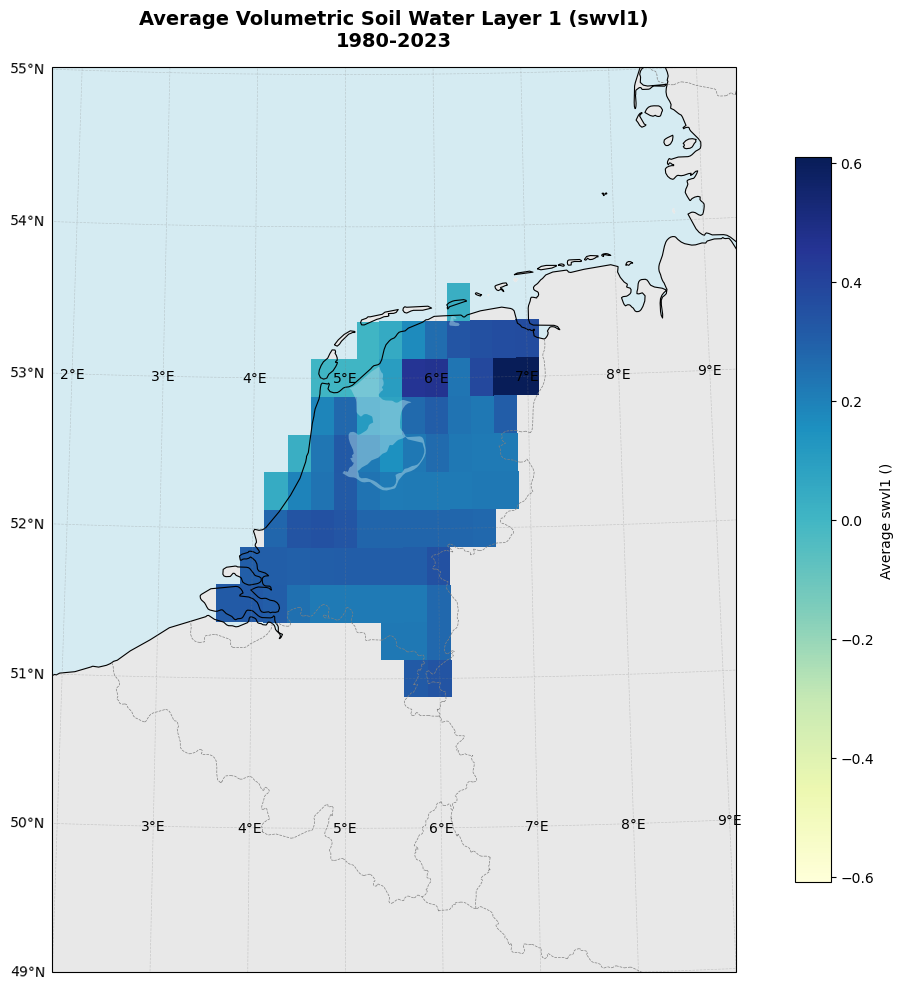

In [26]:
# Create the map plot with LambertConformal projection
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.LambertConformal(
    central_longitude=5, 
    central_latitude=40
))

# Set the extent based on the data coordinates
lon_min = data_to_plot.longitude.min().values
lon_max = data_to_plot.longitude.max().values
lat_min = data_to_plot.latitude.min().values
lat_max = data_to_plot.latitude.max().values

# Add some padding for better visualization
extent = [lon_min - 1, lon_max + 1, lat_min - 1, lat_max + 1]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray', linestyle='--')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax.add_feature(cfeature.LAKES, facecolor='lightblue', alpha=0.5)

# Add gridlines
gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.3, linestyle='--', linewidth=0.5)
gl.top_labels = False
gl.right_labels = False

# Plot the average swvl1 data
im = swvl1_mean.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu',
    cbar_kwargs={
        'label': f'Average {swvl1_mean.attrs.get("long_name", "swvl1")} ({swvl1_mean.attrs.get("units", "")})',
        'shrink': 0.8,
        'pad': 0.05
    }
)

# Add title
ax.set_title('Average Volumetric Soil Water Layer 1 (swvl1)\n1980-2023', 
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

## Step 8: Compute Soil Moisture Deficit Index (SMDI)

Calculate daily Soil Moisture Deficit Index (SMDI) from ERA5 soil moisture data for the Netherlands.

**Algorithm**: Based on Narasimhan and Srinivasan (2005), adapted for daily resolution from its application by Guo et al. (2023)

**Baseline period**: 1980-2023

### Step 8.1: Data Preparation

Calculate the daily mean of hourly soil moisture data, handling leap years

In [27]:
# Step 1: Data Preparation

# Extract the swvl1 variable (volumetric soil moisture)
sm_data = soil_moisture_nl['swvl1'].copy()

sm_daily = sm_data.resample({time_coord: '1D'}).mean()

print(f"Daily soil moisture data shape: {sm_daily.shape}")
print(f"Time range: {sm_daily[time_coord].min().values} to {sm_daily[time_coord].max().values}")

# Extract day-of-year (DOY) for each timestamp
# Handle leap years: combine Feb 28 and Feb 29 (Option A)
time_pd = pd.to_datetime(sm_daily[time_coord].values)
doy = time_pd.dayofyear.values

# For leap years, set Feb 29 (DOY=60) to DOY=59 (combine with Feb 28)
# This creates a 365-day climatology
doy_adjusted = doy.copy()
leap_day_mask = (time_pd.month == 2) & (time_pd.day == 29)
doy_adjusted[leap_day_mask] = 59  # Combine with Feb 28

# Add DOY as a coordinate aligned with valid_time dimension
# Create DataArray with valid_time dimension
doy_coord = xr.DataArray(
    doy_adjusted,
    dims=[time_coord],
    coords={time_coord: sm_daily[time_coord]},
    name='doy'
)
sm_daily = sm_daily.assign_coords(doy=doy_coord)


Daily soil moisture data shape: (16071, 17, 21)
Time range: 1980-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000


### Step 8.2: Calculate Long-term Daily Statistics

For each day-of-year (DOY = 1 to 365), calculate minimum, maximum, and median soil moisture values across all years in ERA5 data.

In [28]:
# Group by DOY and calculate statistics
sm_grouped = sm_daily.groupby('doy')
sm_median_doy = sm_grouped.median(dim='valid_time')

<xarray.DataArray 'swvl1' (doy: 366, latitude: 17, longitude: 21)> Size: 523kB
dask.array<stack, shape=(366, 17, 21), dtype=float32, chunksize=(1, 17, 21), chunktype=numpy.ndarray>
Coordinates:
    number     int64 8B 0
  * latitude   (latitude) float64 136B 54.0 53.75 53.5 53.25 ... 50.5 50.25 50.0
  * longitude  (longitude) float64 168B 3.0 3.25 3.5 3.75 ... 7.25 7.5 7.75 8.0
  * doy        (doy) int32 1kB 1 2 3 4 5 6 7 8 ... 360 361 362 363 364 365 366
Attributes: (12/32)
    GRIB_paramId:                             39
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      357
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m**3 m**-3
    long_name:                                Vol

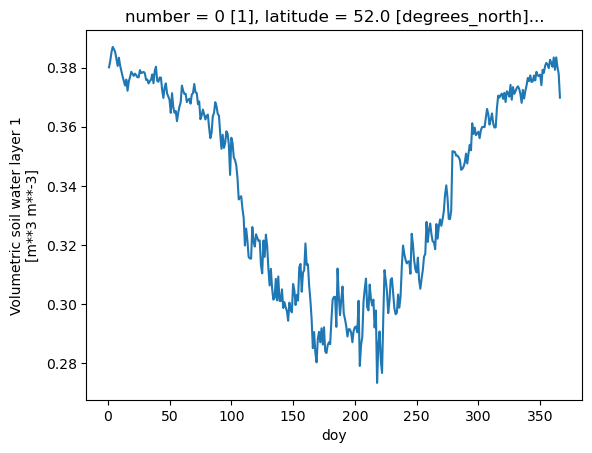

In [29]:
print(sm_median_doy)
sm_median_doy.sel(latitude = 52, longitude = 5).plot()

In [30]:
# Calculate min, max, and median for each DOY
sm_min_doy = sm_grouped.min(dim=time_coord)
sm_max_doy = sm_grouped.max(dim=time_coord)
sm_median_doy = sm_grouped.median(dim=time_coord)


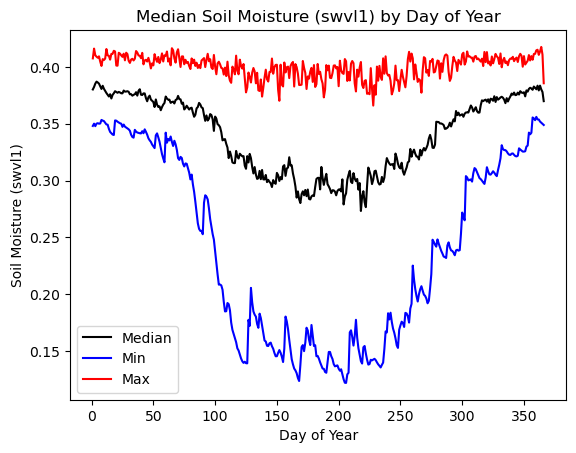

In [31]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
sm_median_doy.sel(latitude = 52, longitude = 5).plot(ax=ax, color = 'black', label = 'Median')
sm_min_doy.sel(latitude = 52, longitude = 5).plot(ax=ax, color = 'blue', label = 'Min')
sm_max_doy.sel(latitude = 52, longitude = 5).plot(ax=ax, color = 'red', label = 'Max')
ax.set_title('Median Soil Moisture (swvl1) by Day of Year')
ax.set_xlabel('Day of Year')
ax.set_ylabel('Soil Moisture (swvl1)')
ax.legend()
plt.show()


### Step 3: Calculate Daily Soil Moisture Deficit (SD)

Calculate the normalized soil moisture deficit for each day using the long-term statistics.

In [32]:
# Function to calculate Soil Moisture Deficit (SD)
def calculate_sd(sm_value, sm_median, sm_min, sm_max):
    """
    Calculate normalized soil moisture deficit (SD).
    
    Parameters:
    -----------
    sm_value : xarray.DataArray
        Current soil moisture value
    sm_median : xarray.DataArray
        Long-term median for this DOY
    sm_min : xarray.DataArray
        Long-term minimum for this DOY
    sm_max : xarray.DataArray
        Long-term maximum for this DOY
    
    Returns:
    --------
    SD : xarray.DataArray
        Normalized soil moisture deficit (-100 to +100)
    """
    # Initialize SD array
    sd = xr.zeros_like(sm_value)
    
    # Case 1: SM <= SM_median
    mask_below_median = sm_value <= sm_median
    denominator_below = sm_median - sm_min
    
    # Handle division by zero: if median == min, set SD = 0
    mask_valid_below = mask_below_median & (denominator_below > 1e-10)
    sd = xr.where(
        mask_valid_below,
        ((sm_value - sm_median) / denominator_below) * 100,
        sd
    )
    
    # Case 2: SM > SM_median
    mask_above_median = sm_value > sm_median
    denominator_above = sm_max - sm_median
    
    # Handle division by zero: if max == median, set SD = 0
    mask_valid_above = mask_above_median & (denominator_above > 1e-10)
    sd = xr.where(
        mask_valid_above,
        ((sm_value - sm_median) / denominator_above) * 100,
        sd
    )
        
    return sd

# Calculate SD for each day
# Map DOY statistics to each time step
print("Calculating daily Soil Moisture Deficit (SD)...")

# Create arrays of statistics aligned with the time dimension
sm_min_aligned = sm_min_doy.sel(doy=sm_daily.doy)
sm_max_aligned = sm_max_doy.sel(doy=sm_daily.doy)
sm_median_aligned = sm_median_doy.sel(doy=sm_daily.doy)

# Calculate SD
SD = calculate_sd(sm_daily, sm_median_aligned, sm_min_aligned, sm_max_aligned)

# Add metadata
SD.attrs['long_name'] = 'Soil Moisture Deficit'
SD.attrs['units'] = 'dimensionless'
SD.attrs['description'] = 'Normalized soil moisture deficit (-100 to +100)'

print(f"SD calculated. Shape: {SD.shape}")
print(f"SD range: {SD.min().values:.2f} to {SD.max().values:.2f}")
print(f"SD mean: {SD.mean().values:.2f}")

Calculating daily Soil Moisture Deficit (SD)...
SD calculated. Shape: (16071, 17, 21)
SD range: -100.00 to 100.00
SD mean: 0.53


### Step 4: Calculate Daily SMDI

Apply the recursive formula to calculate SMDI with decay factor α = 0.5.

In [33]:
@numba.jit(nopython=True, parallel=True)
def calculate_smdi_numba(sd_array, alpha):
    """
    Calculate SMDI recursively using numba for speed.
    
    Parameters:
    -----------
    sd_array : numpy.ndarray
        3D array of SD values (time, lat, lon)
    alpha : float
        Decay factor (0.5)
    
    Returns:
    --------
    smdi_array : numpy.ndarray
        3D array of SMDI values (time, lat, lon)
    """
    n_time, n_lat, n_lon = sd_array.shape
    smdi_array = np.zeros_like(sd_array)
    
    # Initialize first time step
    smdi_array[0, :, :] = sd_array[0, :, :] / 50.0
    
    # Calculate recursively for each spatial point
    for lat in numba.prange(n_lat):  # Parallel over latitude
        for lon in range(n_lon):
            for t in range(1, n_time):
                sd_val = sd_array[t, lat, lon]
                smdi_prev = smdi_array[t-1, lat, lon]
                
                # If SD is finite, apply formula; otherwise decay previous SMDI
                if np.isfinite(sd_val):
                    smdi_array[t, lat, lon] = alpha * smdi_prev + sd_val / 50.0
                else:
                    smdi_array[t, lat, lon] = alpha * smdi_prev
    
    return smdi_array

alpha = 0.5


# Apply the optimized calculation
print(f"Calculating SMDI with numba acceleration (α = {alpha})...")
print("This should take 10-30 seconds...")

# Convert to numpy, calculate, convert back to xarray
sd_numpy = SD.values

smdi_numpy = calculate_smdi_numba(sd_numpy, alpha)

# Create xarray DataArray from result
SMDI = xr.DataArray(
    smdi_numpy,
    coords=SD.coords,
    dims=SD.dims,
    attrs={
        'long_name': 'Soil Moisture Deficit Index',
        'units': 'dimensionless',
        'description': 'Daily SMDI calculated with α=0.5',
        'baseline_period': '1980-2023',
        'decay_factor': alpha,
        'algorithm': 'Narasimhan and Srinivasan (2005), adapted for daily resolution'
    }
)

print(f"\nSMDI calculation complete!")
print(f"SMDI shape: {SMDI.shape}")
print(f"SMDI range: {float(SMDI.min().values):.2f} to {float(SMDI.max().values):.2f}")
print(f"SMDI mean: {float(SMDI.mean().values):.2f}")
print(f"SMDI std: {float(SMDI.std().values):.2f}")


Calculating SMDI with numba acceleration (α = 0.5)...
This should take 10-30 seconds...

SMDI calculation complete!
SMDI shape: (16071, 17, 21)
SMDI range: -4.00 to 4.00
SMDI mean: 0.02
SMDI std: 0.88


### Step 5: Create SMDI Dataset

Organize SMDI and related variables into a dataset for easy access and analysis.

In [34]:
# Create a dataset containing SMDI and related variables
smdi_ds = xr.Dataset({
    'SMDI': SMDI,
    'SD': SD,
    'soil_moisture': sm_daily,
    'doy': (time_coord, doy_adjusted)
})

# Add global attributes
smdi_ds.attrs['title'] = 'Daily Soil Moisture Deficit Index (SMDI) for Netherlands'
smdi_ds.attrs['baseline_period'] = '1980-2023'
smdi_ds.attrs['spatial_coverage'] = 'Netherlands'
smdi_ds.attrs['temporal_resolution'] = 'Daily'
smdi_ds.attrs['decay_factor'] = alpha
smdi_ds.attrs['algorithm_reference'] = 'Narasimhan and Srinivasan (2005)'
smdi_ds.attrs['created'] = pd.Timestamp.now().isoformat()

print("SMDI dataset created:")
print(smdi_ds)

SMDI dataset created:
<xarray.Dataset> Size: 69MB
Dimensions:        (latitude: 17, longitude: 21, valid_time: 16071)
Coordinates:
    number         int64 8B 0
  * latitude       (latitude) float64 136B 54.0 53.75 53.5 ... 50.5 50.25 50.0
  * longitude      (longitude) float64 168B 3.0 3.25 3.5 3.75 ... 7.5 7.75 8.0
  * valid_time     (valid_time) datetime64[ns] 129kB 1980-01-01 ... 2023-12-31
    doy            (valid_time) int32 64kB 1 2 3 4 5 6 ... 361 362 363 364 365
Data variables:
    SMDI           (valid_time, latitude, longitude) float32 23MB 0.0 ... 0.0
    SD             (valid_time, latitude, longitude) float32 23MB dask.array<chunksize=(1, 17, 21), meta=np.ndarray>
    soil_moisture  (valid_time, latitude, longitude) float32 23MB dask.array<chunksize=(1, 17, 21), meta=np.ndarray>
Attributes:
    title:                Daily Soil Moisture Deficit Index (SMDI) for Nether...
    baseline_period:      1980-2023
    spatial_coverage:     Netherlands
    temporal_resolution:  Da

### Step 6: Validation and Visualization

Create time series plots and distribution analysis to validate the SMDI calculation.

/Users/afer/miniforge3/envs/CE_env/lib/python3.13/site-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


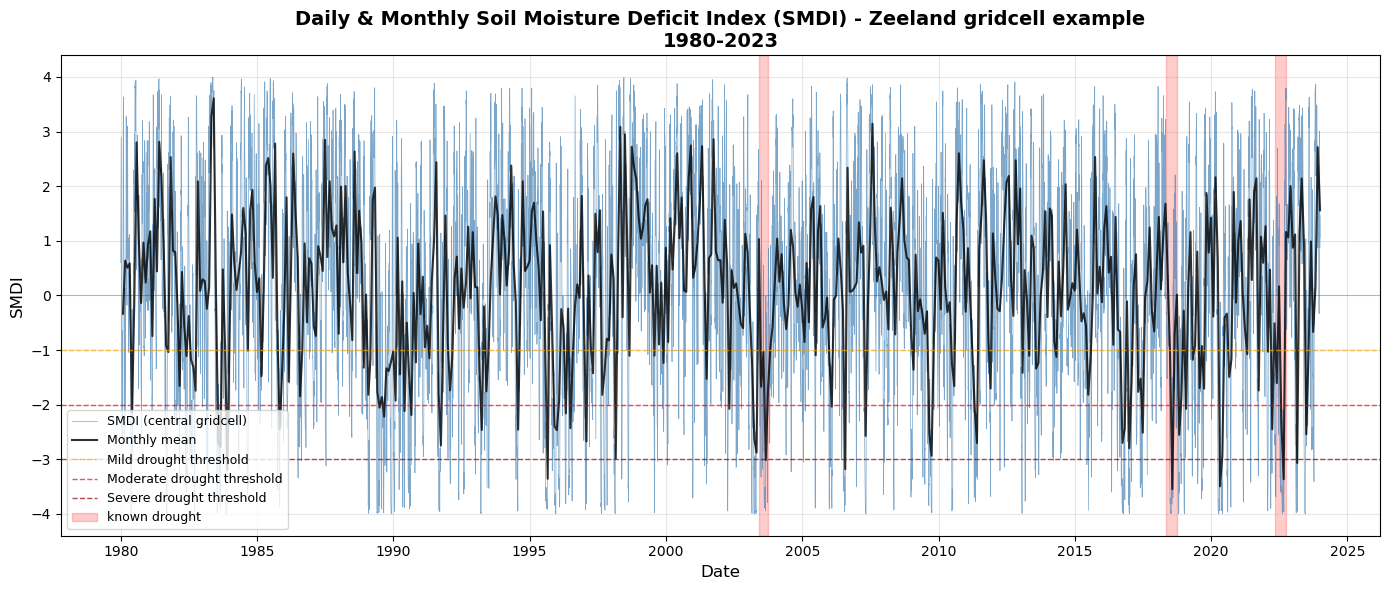

Time series plot created.


In [55]:
# Select a central gridcell for time series visualization
#central_lat = SMDI.latitude.values[len(SMDI.latitude)//2]
#central_lon = SMDI.longitude.values[len(SMDI.longitude)//2]
central_lat = 51.5
central_lon = 3.8
smdi_central_cell = SMDI.sel(latitude=central_lat, longitude=central_lon, method='nearest')

# Create time series plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot SMDI time series for the central gridcell
smdi_central_cell.plot(ax=ax, color='steelblue', linewidth=0.5, alpha=0.7, label='SMDI (central gridcell)')

# Calculate and plot monthly running mean
smdi_monthly_mean = smdi_central_cell.resample({time_coord: '1M'}).mean()
smdi_monthly_mean.plot(ax=ax, color='black', linewidth=1.5, alpha=0.8, label='Monthly mean')

# Add drought threshold lines
ax.axhline(y=-1.0, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Mild drought threshold')
ax.axhline(y=-2.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Moderate drought threshold')
ax.axhline(y=-3.0, color='darkred', linestyle='--', linewidth=1, alpha=0.7, label='Severe drought threshold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)

# Mark known drought events
known_droughts = {
    '2003': ('2003-06-01', '2003-09-30'),
    '2018': ('2018-05-01', '2018-09-30'),
    '2022': ('2022-05-01', '2022-09-30')
}

for year, (start, end) in known_droughts.items():
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), 
               alpha=0.2, color='red', label=f'known drought' if year == '2003' else '')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('SMDI', fontsize=12)
ax.set_title('Daily & Monthly Soil Moisture Deficit Index (SMDI) - Zeeland gridcell example\n1980-2023', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

print("Time series plot created.")

Text(0.98, 0.97, 'Proportion SMDI < 0: 11.13%\nProportion SMDI < -3: 1.36%')

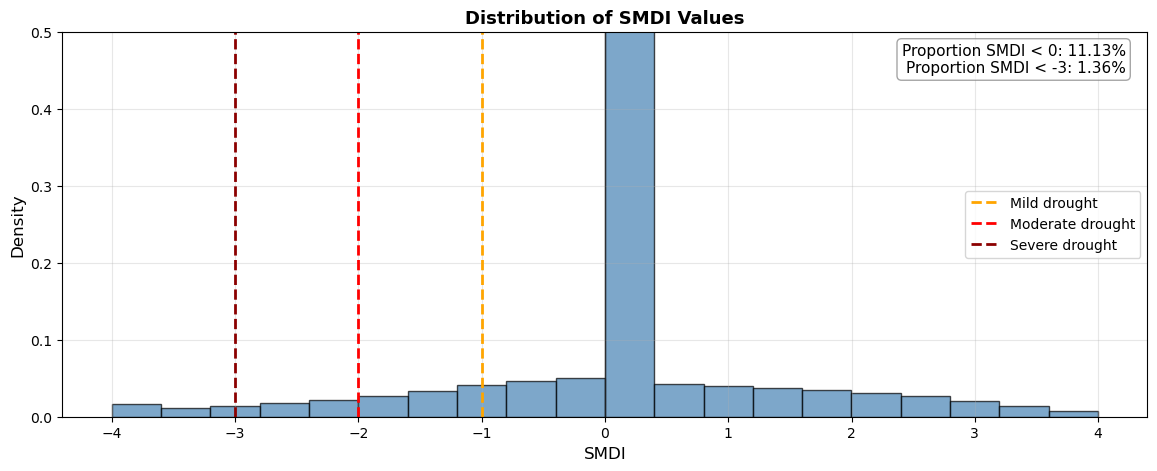

In [65]:
# Distribution plot: Histogram of SMDI values (single panel)
fig, ax = plt.subplots(figsize=(14, 5))

# Flatten data for analysis
smdi_flat = SMDI.values.flatten()
count_below_0 = np.sum(smdi_flat < 0)
count_below_neg3 = np.sum(smdi_flat < -3)

# Histogram
ax.hist(smdi_flat, bins=20, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(x=-1.0, color='orange', linestyle='--', linewidth=2, label='Mild drought')
ax.axvline(x=-2.0, color='red', linestyle='--', linewidth=2, label='Moderate drought')
ax.axvline(x=-3.0, color='darkred', linestyle='--', linewidth=2, label='Severe drought')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_xlabel('SMDI', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of SMDI Values', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.5)

# Display proportions on figure
total_days = len(smdi_flat)
prop_below_0 = count_below_0 / total_days
prop_below_neg3 = count_below_neg3 / total_days
textstr = (
    f'Proportion SMDI < 0: {prop_below_0:.2%}\n'
    f'Proportion SMDI < -3: {prop_below_neg3:.2%}'
)
props = dict[str, str | float](boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray')
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props)


Month coordinate range: 1 to 12
SMDI_monthly sample (first time step): 0.159

Processed 12 months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


/var/folders/p4/7cgg9ywn2hz45fzv3s976d_00000gn/T/ipykernel_24426/4200139282.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(monthly_stats, labels=[f'{m:02d}' for m in months])


<Figure size 640x480 with 0 Axes>

Distribution and seasonal pattern plots created.


### Step 7: Drought Event Identification

Classify drought events based on SMDI thresholds and identify continuous drought periods.

In [ ]:
# Drought classification function
def classify_drought(smdi_value):
    """
    Classify drought severity based on SMDI thresholds.
    
    Returns:
    --------
    str: Drought category
    """
    if smdi_value < -3.0:
        return 'Extreme drought'
    elif smdi_value < -2.0:
        return 'Severe drought'
    elif smdi_value < -1.0:
        return 'Moderate drought'
    elif smdi_value < 0.0:
        return 'Mild drought'
    else:
        return 'No drought'

# Apply classification to spatial average
smdi_spatial_mean_pd = pd.Series(smdi_spatial_mean.values, index=pd.to_datetime(SMDI[time_coord].values))
drought_categories = smdi_spatial_mean_pd.apply(classify_drought)

# Count days in each category
category_counts = drought_categories.value_counts()
print("Drought classification summary (spatial average):")
print(category_counts)
print(f"\nTotal days analyzed: {len(drought_categories)}")
print(f"Percentage of days in drought (SMDI < 0): {(drought_categories != 'No drought').sum() / len(drought_categories) * 100:.1f}%")

In [ ]:
# Identify continuous drought events using runs theory
# Define drought threshold (moderate drought or worse: SMDI < -1.0)
drought_threshold = -1.0
min_duration_days = 7  # Minimum duration for a drought event

# Create boolean mask for drought days
drought_mask = smdi_spatial_mean < drought_threshold

# Find continuous drought periods
drought_periods = []
in_drought = False
start_idx = None

for i in range(len(drought_mask)):
    if drought_mask[i] and not in_drought:
        # Start of drought period
        in_drought = True
        start_idx = i
    elif not drought_mask[i] and in_drought:
        # End of drought period
        in_drought = False
        duration = i - start_idx
        if duration >= min_duration_days:
            start_date = pd.to_datetime(SMDI[time_coord].values[start_idx])
            end_date = pd.to_datetime(SMDI[time_coord].values[i-1])
            mean_smdi = smdi_spatial_mean.isel({time_coord: slice(start_idx, i)}).mean().values
            min_smdi = smdi_spatial_mean.isel({time_coord: slice(start_idx, i)}).min().values
            
            drought_periods.append({
                'start_date': start_date,
                'end_date': end_date,
                'duration_days': duration,
                'mean_smdi': mean_smdi,
                'min_smdi': min_smdi,
                'severity': classify_drought(mean_smdi)
            })
        start_idx = None

# Handle case where drought extends to end of time series
if in_drought:
    duration = len(drought_mask) - start_idx
    if duration >= min_duration_days:
        start_date = pd.to_datetime(SMDI[time_coord].values[start_idx])
        end_date = pd.to_datetime(SMDI[time_coord].values[-1])
        mean_smdi = smdi_spatial_mean.isel({time_coord: slice(start_idx, None)}).mean().values
        min_smdi = smdi_spatial_mean.isel({time_coord: slice(start_idx, None)}).min().values
        
        drought_periods.append({
            'start_date': start_date,
            'end_date': end_date,
            'duration_days': duration,
            'mean_smdi': mean_smdi,
            'min_smdi': min_smdi,
            'severity': classify_drought(mean_smdi)
        })

# Display top drought events
if drought_periods:
    drought_df = pd.DataFrame(drought_periods)
    drought_df = drought_df.sort_values('duration_days', ascending=False)
    
    print(f"\nIdentified {len(drought_periods)} drought events (≥{min_duration_days} days, SMDI < {drought_threshold}):")
    print("\nTop 10 longest drought events:")
    print(drought_df.head(10).to_string(index=False))
    
    # Plot drought events on time series
    fig, ax = plt.subplots(figsize=(14, 6))
    smdi_spatial_mean.plot(ax=ax, color='steelblue', linewidth=0.5, alpha=0.7)
    ax.axhline(y=drought_threshold, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Drought threshold (SMDI < {drought_threshold})')
    
    # Highlight drought events
    for period in drought_periods[:10]:  # Show top 10
        ax.axvspan(period['start_date'], period['end_date'], 
                   alpha=0.3, color='red')
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('SMDI', fontsize=12)
    ax.set_title(f'Drought Events Identified (≥{min_duration_days} days)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"No drought events found with duration ≥ {min_duration_days} days")

### Step 8: Summary Statistics and Export

Generate summary statistics and optionally save the SMDI dataset.

In [ ]:
# Summary statistics
print("="*60)
print("SMDI CALCULATION SUMMARY")
print("="*60)
print(f"\nDataset Information:")
print(f"  Baseline period: 1980-2023")
print(f"  Spatial coverage: Netherlands")
print(f"  Temporal resolution: Daily")
print(f"  Decay factor (α): {alpha}")

print(f"\nSMDI Statistics (all gridcells, all time):")
print(f"  Minimum: {SMDI.min().values:.3f}")
print(f"  Maximum: {SMDI.max().values:.3f}")
print(f"  Mean: {SMDI.mean().values:.3f}")
print(f"  Standard deviation: {SMDI.std().values:.3f}")
print(f"  25th percentile: {np.nanpercentile(SMDI.values, 25):.3f}")
print(f"  50th percentile (median): {np.nanpercentile(SMDI.values, 50):.3f}")
print(f"  75th percentile: {np.nanpercentile(SMDI.values, 75):.3f}")

print(f"\nSpatial Average SMDI Statistics:")
print(f"  Minimum: {smdi_spatial_mean.min().values:.3f}")
print(f"  Maximum: {smdi_spatial_mean.max().values:.3f}")
print(f"  Mean: {smdi_spatial_mean.mean().values:.3f}")
print(f"  Standard deviation: {smdi_spatial_mean.std().values:.3f}")

print(f"\nDrought Classification (spatial average):")
for category in ['Extreme drought', 'Severe drought', 'Moderate drought', 'Mild drought', 'No drought']:
    count = (drought_categories == category).sum()
    percentage = count / len(drought_categories) * 100
    print(f"  {category:20s}: {count:6d} days ({percentage:5.2f}%)")

if drought_periods:
    print(f"\nDrought Events:")
    print(f"  Total events (≥{min_duration_days} days): {len(drought_periods)}")
    print(f"  Average duration: {drought_df['duration_days'].mean():.1f} days")
    print(f"  Longest duration: {drought_df['duration_days'].max():.0f} days")
    print(f"  Most severe event (lowest mean SMDI): {drought_df.loc[drought_df['mean_smdi'].idxmin(), 'start_date'].strftime('%Y-%m-%d')}")

print("\n" + "="*60)

In [ ]:
# Optional: Save SMDI dataset to NetCDF file
# Uncomment the following lines to save:

# output_path = os.path.expanduser('~/CE/ag/Results/SMDI/')
# os.makedirs(output_path, exist_ok=True)
# 
# output_filename = 'SMDI_daily_Netherlands_1980-2023.nc'
# output_filepath = os.path.join(output_path, output_filename)
# 
# print(f"Saving SMDI dataset to: {output_filepath}")
# smdi_ds.to_netcdf(output_filepath)
# print("Dataset saved successfully!")

print("To save the SMDI dataset, uncomment the code above and specify the output path.")

In [ ]:
# Based on SMDI application in Guo et al. 2023;
# Originally formulated by Narasimhan and Srinivasan, 2005

SMDI = 0.5 * MDI + SD/50

### Map view: mean SMDI (1980–2023) + central gridcell marker

This map shows the mean SMDI over the full `valid_time` period, with a star marking the **central gridcell** used in the time series plot above.

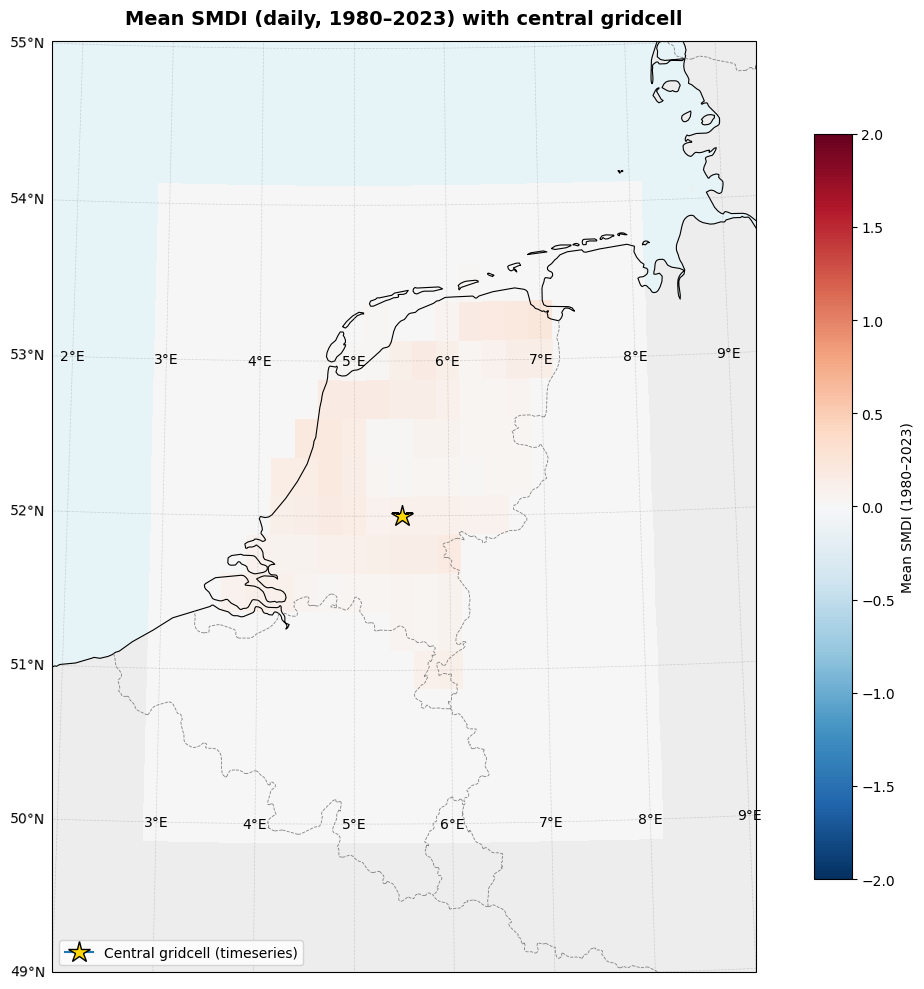